# Ball candidate trajectory explorer

This notebook lets you inspect where `extract_ball_candidates(...)` fires over time.

It gives you two plotting modes:

1. **Top-K per frame**: plot the top `k` candidates from each frame.
2. **Score cutoff**: plot every candidate whose `score >= cutoff`.

You can control:

- the video path
- the start frame
- the number of frames to analyze
- the plotting mode
- the top-K value
- the score cutoff
- the candidate extraction parameters

This notebook uses **OpenCV**, **NumPy**, **Matplotlib**, and **ipywidgets**.


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

from IPython.display import display, clear_output
from matplotlib import cm
from pathlib import Path


ModuleNotFoundError: No module named 'ipywidgets'

## User inputs

Set `diff_video_path` to your differential / grayscale motion video.

If you already have a working `allowed_mask`, you can either keep `allowed_mask_mode = "none"` or use the rectangle / polygon options below.


In [ ]:
# =========================
# USER INPUTS
# =========================

diff_video_path = "diff videos/adjacent_frame_difference.mp4"

# Candidate extraction defaults
default_ball_diameter_px = 10.0
default_diff_thresh = 22
default_min_area_scale = 0.20
default_max_area_scale = 2.50
default_min_bbox_scale = 0.50
default_max_bbox_scale = 1.80
default_min_circularity = 0.35
default_min_mean_intensity = 15.0
default_max_aspect_ratio = 2.20
default_gaussian_blur_ksize = 3

# Plotting defaults
default_start_frame = 0
default_num_frames = 50
default_plot_mode = "top_k"   # "top_k" or "score_cutoff"
default_plot_top_k = 5
default_score_cutoff = 0.25

# Internal collection cap used when gathering candidates in score-cutoff mode.
# Increase this if you think more than this many candidates per frame may survive.
default_collection_top_k = 200

# Allowed-mask settings
allowed_mask_mode = "none"    # "none", "rectangle", or "polygon"
allowed_rect = (0, 0, 400, 400)
allowed_polygon_points = [
    (100, 100),
    (500, 100),
    (550, 350),
    (80, 350),
]


## Exact helper code + `extract_ball_candidates`

The code cell below includes the exact `extract_ball_candidates` implementation copied from your uploaded notebook, along with the helper functions it depends on.


In [ ]:

def get_video_info(video_path):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f"Could not open video: {video_path}")
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = float(cap.get(cv2.CAP_PROP_FPS))
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()
    return {
        "width": width,
        "height": height,
        "fps": fps,
        "frame_count": frame_count,
    }

def read_video_frame(video_path, frame_idx):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f"Could not open video: {video_path}")
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_idx))
    ok, frame = cap.read()
    cap.release()
    if not ok or frame is None:
        raise ValueError(f"Could not read frame {frame_idx} from {video_path}")
    return frame

def to_gray(frame):
    if frame.ndim == 2:
        return frame
    return cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

def maybe_blur(gray, ksize):
    if ksize is None or int(ksize) <= 1:
        return gray
    ksize = int(ksize)
    if ksize % 2 == 0:
        ksize += 1
    return cv2.GaussianBlur(gray, (ksize, ksize), 0)

def threshold_motion(gray, diff_thresh):
    _, binary = cv2.threshold(gray, int(diff_thresh), 255, cv2.THRESH_BINARY)
    return binary

def make_allowed_mask(shape_hw, mode="none", rect=None, polygon_points=None):
    h, w = shape_hw
    mask = np.zeros((h, w), dtype=np.uint8)

    if mode == "none":
        mask[:, :] = 255
        return mask

    if mode == "rectangle":
        if rect is None:
            raise ValueError("rect must be provided for rectangle mode")
        x0, y0, x1, y1 = rect
        x0, x1 = sorted([int(x0), int(x1)])
        y0, y1 = sorted([int(y0), int(y1)])
        x0 = max(0, min(w - 1, x0))
        x1 = max(0, min(w, x1))
        y0 = max(0, min(h - 1, y0))
        y1 = max(0, min(h, y1))
        mask[y0:y1, x0:x1] = 255
        return mask

    if mode == "polygon":
        if polygon_points is None or len(polygon_points) < 3:
            raise ValueError("polygon_points must contain at least 3 points")
        pts = np.array(polygon_points, dtype=np.int32)
        cv2.fillPoly(mask, [pts], 255)
        return mask

    raise ValueError(f"Unknown mode: {mode}")

def circularity_from_stats(area, perimeter):
    if perimeter <= 0:
        return 0.0
    return float(4.0 * np.pi * area / (perimeter ** 2))

def extract_ball_candidates(
    diff_gray,
    ball_diameter_px,
    diff_thresh=22,
    min_area_scale=0.20,
    max_area_scale=2.50,
    min_bbox_scale=0.50,
    max_bbox_scale=1.80,
    min_circularity=0.35,
    min_mean_intensity=15.0,
    max_aspect_ratio=2.20,
    top_k=5,
    allowed_mask=None,
    gaussian_blur_ksize=3,
):
    diff_gray = to_gray(diff_gray)
    proc_gray = maybe_blur(diff_gray, gaussian_blur_ksize)
    binary = threshold_motion(proc_gray, diff_thresh)

    if allowed_mask is not None:
        binary = cv2.bitwise_and(binary, allowed_mask)

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary, connectivity=8)

    expected_area = np.pi * (ball_diameter_px / 2.0) ** 2
    min_area = min_area_scale * expected_area
    max_area = max_area_scale * expected_area
    min_bbox = min_bbox_scale * ball_diameter_px
    max_bbox = max_bbox_scale * ball_diameter_px

    candidates = []

    for label_id in range(1, num_labels):
        x = stats[label_id, cv2.CC_STAT_LEFT]
        y = stats[label_id, cv2.CC_STAT_TOP]
        w = stats[label_id, cv2.CC_STAT_WIDTH]
        h = stats[label_id, cv2.CC_STAT_HEIGHT]
        area = float(stats[label_id, cv2.CC_STAT_AREA])

        if area < min_area or area > max_area:
            continue
        if w < min_bbox or h < min_bbox:
            continue
        if w > max_bbox or h > max_bbox:
            continue

        aspect_ratio = max(w / max(h, 1), h / max(w, 1))
        if aspect_ratio > max_aspect_ratio:
            continue

        component_mask = (labels == label_id).astype(np.uint8) * 255
        contours, _ = cv2.findContours(component_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            continue
        cnt = max(contours, key=cv2.contourArea)
        perimeter = float(cv2.arcLength(cnt, closed=True))
        circularity = circularity_from_stats(area, perimeter)
        if circularity < min_circularity:
            continue

        mean_intensity = float(cv2.mean(diff_gray, mask=component_mask)[0])
        if mean_intensity < min_mean_intensity:
            continue

        cx, cy = centroids[label_id]
        radius_est = 0.25 * (w + h)

        area_ratio = area / max(expected_area, 1e-6)
        area_score = 1.0 / (1.0 + abs(np.log(max(area_ratio, 1e-6))))
        circle_score = circularity
        intensity_score = mean_intensity / 255.0
        aspect_score = 1.0 / max(aspect_ratio, 1.0)

        score = (
            0 * area_score
            + 0.30 * circle_score
            + 0.60 * intensity_score
            + 0.10 * aspect_score
        )

        candidates.append({
            "label_id": int(label_id),
            "x": int(x),
            "y": int(y),
            "w": int(w),
            "h": int(h),
            "cx": float(cx),
            "cy": float(cy),
            "area": float(area),
            "mean_intensity": float(mean_intensity),
            "circularity": float(circularity),
            "aspect_ratio": float(aspect_ratio),
            "radius_est": float(radius_est),
            "score": float(score),
        })

    candidates = sorted(candidates, key=lambda c: c["score"], reverse=True)
    return candidates[:top_k], {
        "diff_gray": diff_gray,
        "proc_gray": proc_gray,
        "binary": binary,
        "labels": labels,
        "stats": stats,
        "centroids": centroids,
        "expected_area": expected_area,
        "num_labels": num_labels,
    }

def draw_candidates_on_frame(gray_frame, candidates, allowed_mask=None, show_labels=True):
    if gray_frame.ndim == 2:
        overlay = cv2.cvtColor(gray_frame, cv2.COLOR_GRAY2BGR)
    else:
        overlay = gray_frame.copy()

    if allowed_mask is not None:
        boundary = cv2.Canny(allowed_mask, 50, 150)
        overlay[boundary > 0] = (255, 255, 0)

    for i, c in enumerate(candidates):
        cx, cy = int(round(c["cx"])), int(round(c["cy"]))
        r = max(2, int(round(c["radius_est"])))
        cv2.circle(overlay, (cx, cy), r, (0, 255, 0), 2)
        cv2.rectangle(overlay, (c["x"], c["y"]), (c["x"] + c["w"], c["y"] + c["h"]), (0, 128, 255), 1)
        if show_labels:
            txt = f"{i+1}: {c['score']:.2f}"
            cv2.putText(overlay, txt, (cx + 4, cy - 4), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 255, 255), 1, cv2.LINE_AA)
    return overlay

def parse_polygon_text(text):
    lines = [ln.strip() for ln in text.strip().splitlines() if ln.strip()]
    pts = []
    for ln in lines:
        parts = ln.replace(",", " ").split()
        if len(parts) != 2:
            continue
        x, y = float(parts[0]), float(parts[1])
        pts.append((int(round(x)), int(round(y))))
    return pts

def preview_detection(
    video_path,
    frame_idx,
    ball_diameter_px,
    diff_thresh,
    min_area_scale,
    max_area_scale,
    min_bbox_scale,
    max_bbox_scale,
    min_circularity,
    min_mean_intensity,
    max_aspect_ratio,
    top_k,
    gaussian_blur_ksize,
    region_mode,
    rect_x0,
    rect_y0,
    rect_x1,
    rect_y1,
    polygon_text,
    show_binary=True,
    show_processed=False,
):
    frame = read_video_frame(video_path, frame_idx)
    gray = to_gray(frame)

    allowed_mask = None
    polygon_points = None
    if region_mode == "rectangle":
        allowed_mask = make_allowed_mask(
            gray.shape,
            mode="rectangle",
            rect=(rect_x0, rect_y0, rect_x1, rect_y1),
        )
    elif region_mode == "polygon":
        polygon_points = parse_polygon_text(polygon_text)
        allowed_mask = make_allowed_mask(
            gray.shape,
            mode="polygon",
            polygon_points=polygon_points,
        )

    candidates, debug = extract_ball_candidates(
        diff_gray=gray,
        ball_diameter_px=ball_diameter_px,
        diff_thresh=diff_thresh,
        min_area_scale=min_area_scale,
        max_area_scale=max_area_scale,
        min_bbox_scale=min_bbox_scale,
        max_bbox_scale=max_bbox_scale,
        min_circularity=min_circularity,
        min_mean_intensity=min_mean_intensity,
        max_aspect_ratio=max_aspect_ratio,
        top_k=top_k,
        allowed_mask=allowed_mask,
        gaussian_blur_ksize=gaussian_blur_ksize,
    )

    overlay = draw_candidates_on_frame(gray, candidates, allowed_mask=allowed_mask, show_labels=True)

    cols = 3 if (show_binary or show_processed) else 1
    fig, axes = plt.subplots(1, cols, figsize=(6 * cols, 6))

    if cols == 1:
        axes = [axes]

    ax0 = axes[0]
    ax0.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    ax0.set_title(f"Overlay on frame {frame_idx}")
    ax0.axis("off")

    next_ax = 1
    if show_binary:
        axes[next_ax].imshow(debug["binary"], cmap="gray", vmin=0, vmax=255)
        axes[next_ax].set_title("Thresholded / filtered mask")
        axes[next_ax].axis("off")
        next_ax += 1

    if show_processed:
        axes[next_ax].imshow(debug["proc_gray"], cmap="gray", vmin=0, vmax=255)
        axes[next_ax].set_title("Processed grayscale")
        axes[next_ax].axis("off")

    plt.tight_layout()
    plt.show()

    print(f"Frame: {frame_idx}")
    print(f"Candidates returned: {len(candidates)}")
    print(f"Expected ball area: {debug['expected_area']:.2f} px^2")
    print()

    if len(candidates) == 0:
        print("No candidates found with current parameters.")
    else:
        for i, c in enumerate(candidates, start=1):
            print(
                f"{i}. center=({c['cx']:.1f}, {c['cy']:.1f}) "
                f"bbox=({c['w']}x{c['h']}) area={c['area']:.1f} "
                f"circ={c['circularity']:.3f} mean={c['mean_intensity']:.1f} "
                f"aspect={c['aspect_ratio']:.2f} score={c['score']:.3f}"
            )

    return candidates, debug, overlay


## Small helpers for trajectory exploration

In [ ]:

video_info = get_video_info(diff_video_path)
video_info

def build_allowed_mask_for_video(shape_hw, mode, rect=None, polygon_points=None):
    if mode == "none":
        return None
    return make_allowed_mask(
        shape_hw=shape_hw,
        mode=mode,
        rect=rect,
        polygon_points=polygon_points,
    )

def read_diff_gray_frame(video_path, frame_idx):
    frame = read_video_frame(video_path, frame_idx)
    return to_gray(frame)

def collect_ball_candidate_history(
    video_path,
    start_frame,
    num_frames,
    *,
    ball_diameter_px,
    diff_thresh,
    min_area_scale,
    max_area_scale,
    min_bbox_scale,
    max_bbox_scale,
    min_circularity,
    min_mean_intensity,
    max_aspect_ratio,
    gaussian_blur_ksize,
    allowed_mask,
    plot_mode="top_k",
    plot_top_k=5,
    score_cutoff=0.25,
    collection_top_k=200,
):
    info = get_video_info(video_path)
    frame_count = info["frame_count"]

    start_frame = int(np.clip(start_frame, 0, max(frame_count - 1, 0)))
    num_frames = max(1, int(num_frames))
    end_frame = min(start_frame + num_frames, frame_count)

    background = read_diff_gray_frame(video_path, start_frame)

    all_points = []
    per_frame_counts = []

    if plot_mode == "top_k":
        extract_top_k = max(int(plot_top_k), 1)
    else:
        extract_top_k = max(int(collection_top_k), 1)

    for frame_idx in range(start_frame, end_frame):
        gray = read_diff_gray_frame(video_path, frame_idx)

        candidates, debug = extract_ball_candidates(
            diff_gray=gray,
            ball_diameter_px=ball_diameter_px,
            diff_thresh=diff_thresh,
            min_area_scale=min_area_scale,
            max_area_scale=max_area_scale,
            min_bbox_scale=min_bbox_scale,
            max_bbox_scale=max_bbox_scale,
            min_circularity=min_circularity,
            min_mean_intensity=min_mean_intensity,
            max_aspect_ratio=max_aspect_ratio,
            top_k=extract_top_k,
            allowed_mask=allowed_mask,
            gaussian_blur_ksize=gaussian_blur_ksize,
        )

        if plot_mode == "top_k":
            selected = candidates[:max(int(plot_top_k), 0)]
        elif plot_mode == "score_cutoff":
            selected = [c for c in candidates if c["score"] >= float(score_cutoff)]
        else:
            raise ValueError(f"Unknown plot_mode: {plot_mode}")

        per_frame_counts.append(len(selected))

        for rank, cand in enumerate(selected, start=1):
            all_points.append({
                "frame_idx": int(frame_idx),
                "relative_frame": int(frame_idx - start_frame),
                "rank": int(rank),
                "cx": float(cand["cx"]),
                "cy": float(cand["cy"]),
                "score": float(cand["score"]),
            })

    return {
        "background_gray": background,
        "points": all_points,
        "per_frame_counts": per_frame_counts,
        "start_frame": int(start_frame),
        "end_frame": int(end_frame),
        "num_frames_used": int(end_frame - start_frame),
        "frame_count": int(frame_count),
    }

def plot_ball_candidate_history(
    history,
    *,
    plot_mode="top_k",
    plot_top_k=5,
    score_cutoff=0.25,
    point_size=50,
    show_frame_labels=False,
):
    bg = history["background_gray"]
    points = history["points"]
    start_frame = history["start_frame"]
    end_frame = history["end_frame"]

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(bg, cmap="gray", vmin=0, vmax=255)
    ax.set_title(
        f"Ball candidate locations, frames {start_frame} to {end_frame - 1} "
        f"({'top_k=' + str(plot_top_k) if plot_mode == 'top_k' else 'score>=' + str(score_cutoff)})"
    )
    ax.set_xlabel("x")
    ax.set_ylabel("y")

    if len(points) == 0:
        ax.text(
            0.5, 0.5, "No candidates matched the current settings",
            transform=ax.transAxes, ha="center", va="center",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.9),
        )
        plt.show()
        return

    num_frames = max(history["num_frames_used"], 1)
    cmap = cm.get_cmap("viridis", num_frames)

    xs = [p["cx"] for p in points]
    ys = [p["cy"] for p in points]
    colors = [cmap(p["relative_frame"] / max(num_frames - 1, 1)) for p in points]
    sizes = [point_size for _ in points]

    ax.scatter(xs, ys, s=sizes, c=colors, edgecolors="white", linewidths=0.5)

    if show_frame_labels:
        for p in points:
            ax.text(
                p["cx"] + 2, p["cy"] + 2, str(p["frame_idx"]),
                fontsize=7, color="white",
                bbox=dict(facecolor="black", alpha=0.4, pad=1),
            )

    first_proxy = ax.scatter([], [], s=point_size, color=cmap(0.0), label=f"frame {start_frame}")
    last_proxy = ax.scatter([], [], s=point_size, color=cmap(1.0), label=f"frame {end_frame - 1}")
    ax.legend(handles=[first_proxy, last_proxy], loc="upper right")

    ax.set_xlim(0, bg.shape[1] - 1)
    ax.set_ylim(bg.shape[0] - 1, 0)
    plt.tight_layout()
    plt.show()

    print(f"Frames analyzed: {start_frame} to {end_frame - 1} ({history['num_frames_used']} frames)")
    print(f"Total plotted candidates: {len(points)}")
    print(f"Per-frame counts: {history['per_frame_counts']}")


## Interactive controls

Click **Run / refresh plot** after changing settings.


In [ ]:

video_info = get_video_info(diff_video_path)

start_frame_widget = widgets.IntSlider(
    value=min(default_start_frame, max(video_info["frame_count"] - 1, 0)),
    min=0,
    max=max(video_info["frame_count"] - 1, 0),
    step=1,
    description="start",
    continuous_update=False,
    layout=widgets.Layout(width="500px"),
)

num_frames_widget = widgets.IntSlider(
    value=min(default_num_frames, max(video_info["frame_count"], 1)),
    min=1,
    max=max(video_info["frame_count"], 1),
    step=1,
    description="frames",
    continuous_update=False,
    layout=widgets.Layout(width="500px"),
)

plot_mode_widget = widgets.Dropdown(
    options=[("Top K / frame", "top_k"), ("Score cutoff", "score_cutoff")],
    value=default_plot_mode,
    description="mode",
    layout=widgets.Layout(width="300px"),
)

plot_top_k_widget = widgets.IntSlider(
    value=default_plot_top_k,
    min=1,
    max=20,
    step=1,
    description="top k",
    continuous_update=False,
    layout=widgets.Layout(width="500px"),
)

score_cutoff_widget = widgets.FloatSlider(
    value=default_score_cutoff,
    min=0.0,
    max=1.0,
    step=0.01,
    description="score cut",
    continuous_update=False,
    readout_format=".2f",
    layout=widgets.Layout(width="500px"),
)

collection_top_k_widget = widgets.IntSlider(
    value=default_collection_top_k,
    min=10,
    max=1000,
    step=10,
    description="collect k",
    continuous_update=False,
    layout=widgets.Layout(width="500px"),
)

ball_diameter_widget = widgets.FloatSlider(
    value=default_ball_diameter_px,
    min=2.0,
    max=40.0,
    step=0.5,
    description="ball px",
    continuous_update=False,
    layout=widgets.Layout(width="500px"),
)

diff_thresh_widget = widgets.IntSlider(
    value=default_diff_thresh,
    min=1,
    max=255,
    step=1,
    description="thresh",
    continuous_update=False,
    layout=widgets.Layout(width="500px"),
)

min_area_scale_widget = widgets.FloatSlider(
    value=default_min_area_scale,
    min=0.01,
    max=2.0,
    step=0.01,
    description="min area",
    continuous_update=False,
    layout=widgets.Layout(width="500px"),
)

max_area_scale_widget = widgets.FloatSlider(
    value=default_max_area_scale,
    min=0.10,
    max=8.0,
    step=0.05,
    description="max area",
    continuous_update=False,
    layout=widgets.Layout(width="500px"),
)

min_bbox_scale_widget = widgets.FloatSlider(
    value=default_min_bbox_scale,
    min=0.10,
    max=2.0,
    step=0.05,
    description="min bbox",
    continuous_update=False,
    layout=widgets.Layout(width="500px"),
)

max_bbox_scale_widget = widgets.FloatSlider(
    value=default_max_bbox_scale,
    min=0.20,
    max=5.0,
    step=0.05,
    description="max bbox",
    continuous_update=False,
    layout=widgets.Layout(width="500px"),
)

min_circularity_widget = widgets.FloatSlider(
    value=default_min_circularity,
    min=0.0,
    max=1.2,
    step=0.01,
    description="circular",
    continuous_update=False,
    layout=widgets.Layout(width="500px"),
)

min_mean_intensity_widget = widgets.FloatSlider(
    value=default_min_mean_intensity,
    min=0.0,
    max=255.0,
    step=1.0,
    description="mean int",
    continuous_update=False,
    layout=widgets.Layout(width="500px"),
)

max_aspect_ratio_widget = widgets.FloatSlider(
    value=default_max_aspect_ratio,
    min=1.0,
    max=6.0,
    step=0.05,
    description="aspect",
    continuous_update=False,
    layout=widgets.Layout(width="500px"),
)

gaussian_blur_widget = widgets.IntSlider(
    value=default_gaussian_blur_ksize,
    min=0,
    max=21,
    step=1,
    description="blur k",
    continuous_update=False,
    layout=widgets.Layout(width="500px"),
)

show_frame_labels_widget = widgets.Checkbox(
    value=False,
    description="label plotted points with frame number",
)

run_button = widgets.Button(
    description="Run / refresh plot",
    button_style="primary",
)

output = widgets.Output()

def on_run_button_clicked(_):
    with output:
        clear_output(wait=True)

        allowed_mask = build_allowed_mask_for_video(
            shape_hw=(video_info["height"], video_info["width"]),
            mode=allowed_mask_mode,
            rect=allowed_rect,
            polygon_points=allowed_polygon_points,
        )

        history = collect_ball_candidate_history(
            video_path=diff_video_path,
            start_frame=start_frame_widget.value,
            num_frames=num_frames_widget.value,
            ball_diameter_px=ball_diameter_widget.value,
            diff_thresh=diff_thresh_widget.value,
            min_area_scale=min_area_scale_widget.value,
            max_area_scale=max_area_scale_widget.value,
            min_bbox_scale=min_bbox_scale_widget.value,
            max_bbox_scale=max_bbox_scale_widget.value,
            min_circularity=min_circularity_widget.value,
            min_mean_intensity=min_mean_intensity_widget.value,
            max_aspect_ratio=max_aspect_ratio_widget.value,
            gaussian_blur_ksize=gaussian_blur_widget.value,
            allowed_mask=allowed_mask,
            plot_mode=plot_mode_widget.value,
            plot_top_k=plot_top_k_widget.value,
            score_cutoff=score_cutoff_widget.value,
            collection_top_k=collection_top_k_widget.value,
        )

        plot_ball_candidate_history(
            history,
            plot_mode=plot_mode_widget.value,
            plot_top_k=plot_top_k_widget.value,
            score_cutoff=score_cutoff_widget.value,
            show_frame_labels=show_frame_labels_widget.value,
        )

        if history["points"]:
            print("\nFirst few plotted points:")
            for p in history["points"][:10]:
                print(
                    f"frame={p['frame_idx']}, x={p['cx']:.1f}, y={p['cy']:.1f}, "
                    f"score={p['score']:.3f}, rank={p['rank']}"
                )

run_button.on_click(on_run_button_clicked)

controls = widgets.VBox([
    widgets.HTML("<h4>Plot controls</h4>"),
    start_frame_widget,
    num_frames_widget,
    plot_mode_widget,
    plot_top_k_widget,
    score_cutoff_widget,
    collection_top_k_widget,
    show_frame_labels_widget,
    widgets.HTML("<h4>Candidate extraction parameters</h4>"),
    ball_diameter_widget,
    diff_thresh_widget,
    min_area_scale_widget,
    max_area_scale_widget,
    min_bbox_scale_widget,
    max_bbox_scale_widget,
    min_circularity_widget,
    min_mean_intensity_widget,
    max_aspect_ratio_widget,
    gaussian_blur_widget,
    run_button,
])

display(controls, output)


Output()

## Optional: one-shot non-interactive call

This cell is useful if you want a plain Python call without the widgets.


/var/folders/5j/49_zrbvs4l7_06093vcjrymh0000gn/T/ipykernel_57809/567221456.py:137: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis", num_frames)


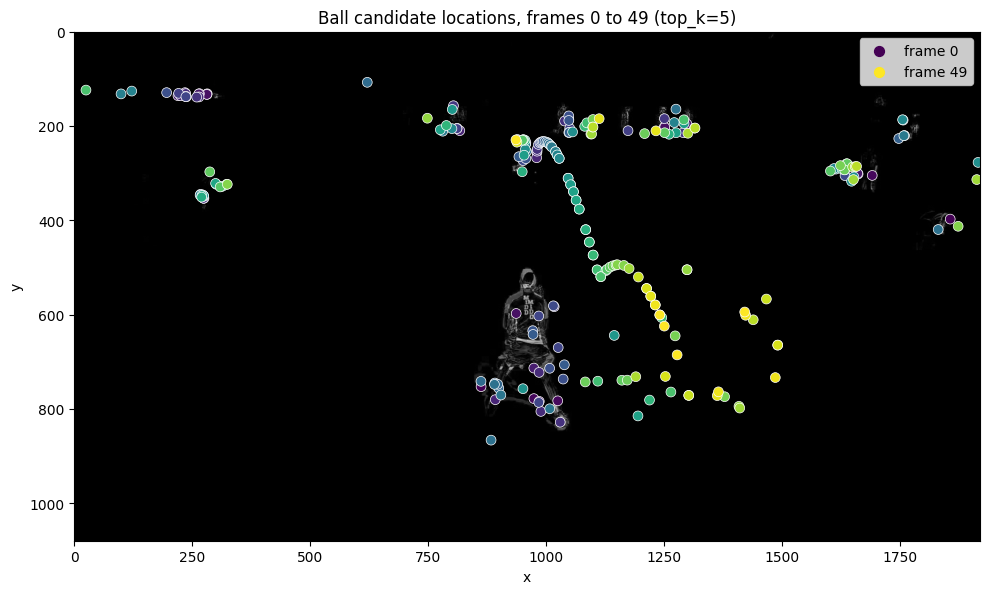

Frames analyzed: 0 to 49 (50 frames)
Total plotted candidates: 250
Per-frame counts: [5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5]


In [ ]:
allowed_mask = build_allowed_mask_for_video(
    shape_hw=(video_info["height"], video_info["width"]),
    mode=allowed_mask_mode,
    rect=allowed_rect,
    polygon_points=allowed_polygon_points,
)

history = collect_ball_candidate_history(
    video_path=diff_video_path,
    start_frame=default_start_frame,
    num_frames=default_num_frames,
    ball_diameter_px=default_ball_diameter_px,
    diff_thresh=default_diff_thresh,
    min_area_scale=default_min_area_scale,
    max_area_scale=default_max_area_scale,
    min_bbox_scale=default_min_bbox_scale,
    max_bbox_scale=default_max_bbox_scale,
    min_circularity=default_min_circularity,
    min_mean_intensity=default_min_mean_intensity,
    max_aspect_ratio=default_max_aspect_ratio,
    gaussian_blur_ksize=default_gaussian_blur_ksize,
    allowed_mask=allowed_mask,
    plot_mode=default_plot_mode,
    plot_top_k=default_plot_top_k,
    score_cutoff=default_score_cutoff,
    collection_top_k=default_collection_top_k,
)

plot_ball_candidate_history(
    history,
    plot_mode=default_plot_mode,
    plot_top_k=default_plot_top_k,
    score_cutoff=default_score_cutoff,
)


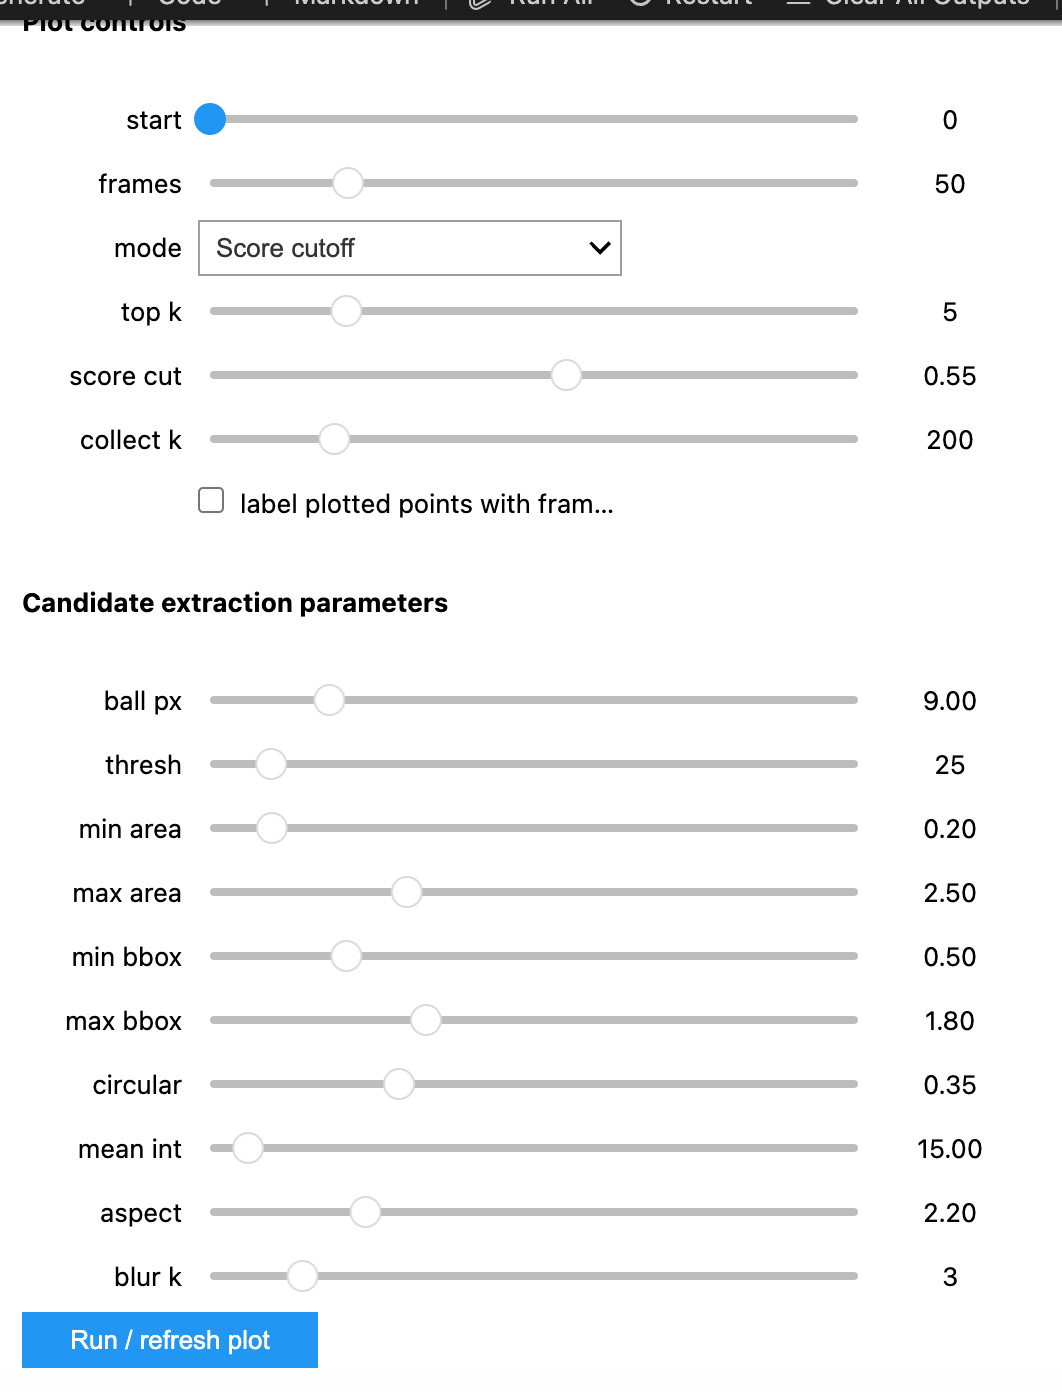